In [1]:
import numpy as np
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pytensor.tensor as pt
import pymc as pm
from scipy.stats import norm
from pathlib import Path
import pytensor

plt.rcParams["figure.constrained_layout.use"] = True

## Visualisation

In [4]:
weighted_update_df = pd.read_csv(
    Path.cwd().parent.parent / "results" / "weighted_update_summary.csv"
)
weighted_update_df = weighted_update_df[weighted_update_df.session == 2]

In [5]:
weighted_update_df.columns

Index(['participant_id', 'session', 'sensitivity', 'pi_cardiac_belief',
       'sigma_cardiac_prior', 'mu_cardiac_prior'],
      dtype='object')

In [11]:
np.log(weighted_update_df.sensitivity) - np.log(
    (1 / weighted_update_df.sigma_cardiac_prior**2) - weighted_update_df.sensitivity
)

1           NaN
4           NaN
6      0.160622
8           NaN
10    -1.597714
         ...   
731         NaN
732         NaN
733         NaN
734         NaN
735         NaN
Length: 518, dtype: float64

<Axes: >

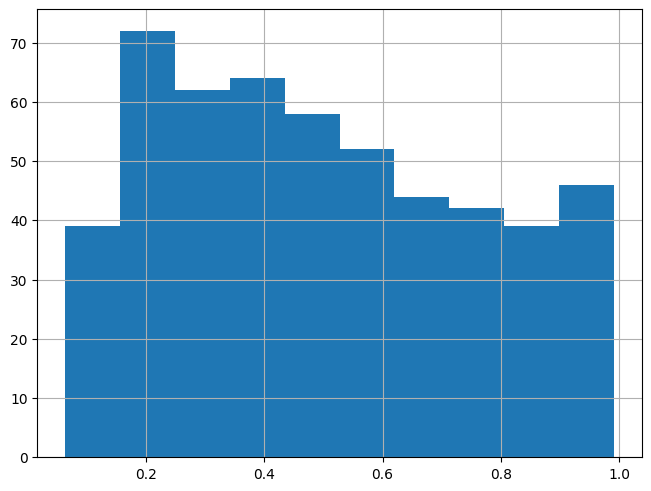

In [17]:
weighted_update_df.sensitivity.hist()

(array([ 21.,  84.,  94., 119.,  85.,  51.,  23.,  22.,  15.,   4.]),
 array([-2.69878723, -1.95224416, -1.20570109, -0.45915802,  0.28738505,
         1.03392812,  1.78047119,  2.52701426,  3.27355733,  4.02010039,
         4.76664346]),
 <BarContainer object of 10 artists>)

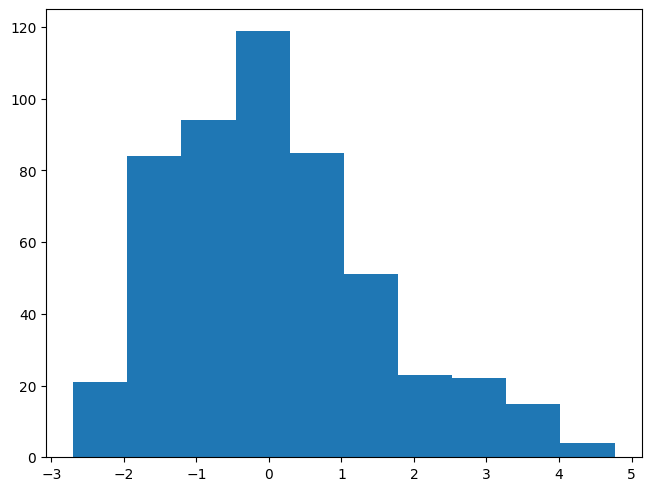

In [16]:
plt.hist(np.log(weighted_update_df.sensitivity / (1 - weighted_update_df.sensitivity)))

In [ ]:
_, ax = plt.subplots(figsize=(9, 4))

sns.histplot(
    cardiac_hrd_df.logit_exteroceptive_sensitivity.to_numpy(),
    color="#4c72b0",
    alpha=0.8,
    stat="proportion",
    binwidth=1,
    binrange=(-10, 40),
    label="Exteroception",
    ax=ax,
)

sns.histplot(
    cardiac_hrd_df.logit_interoceptive_sensitivity.to_numpy(),
    color="#c44e52",
    alpha=0.8,
    stat="proportion",
    binwidth=1,
    binrange=(-10, 40),
    label="Interoception",
    ax=ax,
)
ax.set(
    title="Interoceptive and exteroceptive sensitivity scores distributions",
    xlabel="Normalised sensitivity",
)
ax.legend()
ax.minorticks_on()
sns.despine()

## Cardiac HGF

In [2]:
cardiac_hrd_df = pd.read_csv(
    Path.cwd().parent.parent / "results" / "cardiac_hgf_summary.csv"
)
cardiac_hrd_df = cardiac_hrd_df[cardiac_hrd_df.session == 2]

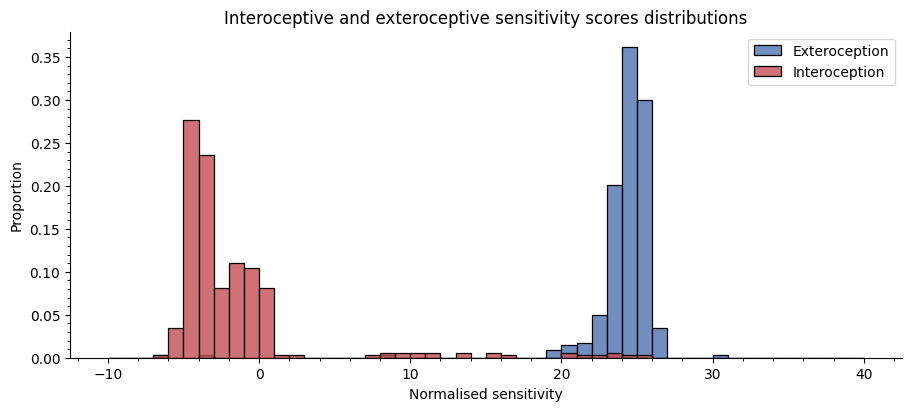

In [3]:
_, ax = plt.subplots(figsize=(9, 4))

sns.histplot(
    cardiac_hrd_df.logit_exteroceptive_sensitivity.to_numpy(),
    color="#4c72b0",
    alpha=0.8,
    stat="proportion",
    binwidth=1,
    binrange=(-10, 40),
    label="Exteroception",
    ax=ax,
)

sns.histplot(
    cardiac_hrd_df.logit_interoceptive_sensitivity.to_numpy(),
    color="#c44e52",
    alpha=0.8,
    stat="proportion",
    binwidth=1,
    binrange=(-10, 40),
    label="Interoception",
    ax=ax,
)
ax.set(
    title="Interoceptive and exteroceptive sensitivity scores distributions",
    xlabel="Normalised sensitivity",
)
ax.legend()
ax.minorticks_on()
sns.despine()

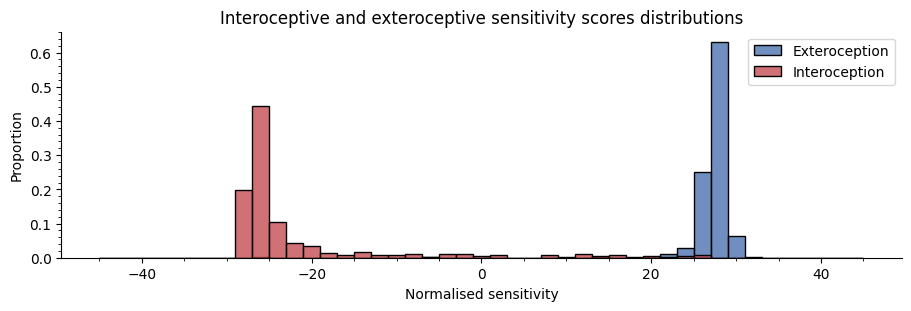

In [4]:
_, ax = plt.subplots(figsize=(9, 3))

sns.histplot(
    cardiac_hrd_df.exteroceptive_tonic_volatility.to_numpy(),
    color="#4c72b0",
    alpha=0.8,
    stat="proportion",
    binwidth=2,
    binrange=(-45, 45),
    label="Exteroception",
    ax=ax,
)

sns.histplot(
    cardiac_hrd_df.interoceptive_tonic_volatility.to_numpy(),
    color="#c44e52",
    alpha=0.8,
    stat="proportion",
    binwidth=2,
    binrange=(-45, 45),
    label="Interoception",
    ax=ax,
)
ax.set(
    title="Interoceptive and exteroceptive sensitivity scores distributions",
    xlabel="Normalised sensitivity",
)
ax.legend()
ax.minorticks_on()
sns.despine()

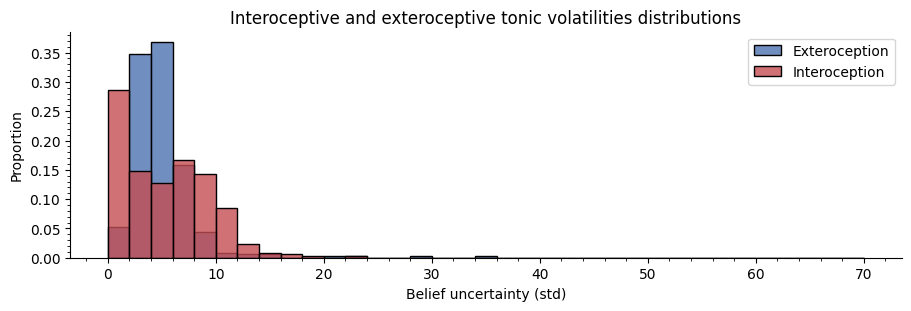

In [5]:
_, ax = plt.subplots(figsize=(9, 3))

sns.histplot(
    np.sqrt(1 / cardiac_hrd_df.exteroceptive_precision.to_numpy()),
    color="#4c72b0",
    alpha=0.8,
    stat="proportion",
    binwidth=2,
    binrange=(0, 70),
    label="Exteroception",
    ax=ax,
)

sns.histplot(
    np.sqrt(1 / cardiac_hrd_df.interoceptive_precision.to_numpy()),
    color="#c44e52",
    alpha=0.8,
    stat="proportion",
    binwidth=2,
    binrange=(0, 70),
    label="Interoception",
    ax=ax,
)
ax.set(
    title="Interoceptive and exteroceptive tonic volatilities distributions",
    xlabel="Belief uncertainty (std)",
)
ax.legend()
ax.minorticks_on()
sns.despine()

## Interoception

In [13]:
interoceptive_precision = az.summary(idata, var_names=["interoceptive_precision"])[
    "mean"
].values.item()
interoceptive_mean = az.summary(idata, var_names=["interoceptive_mean"])[
    "mean"
].values.item()
interoceptive_tonic_volatility = az.summary(
    idata, var_names=["interoceptive_tonic_volatility"]
)["mean"].values.item()

In [14]:
intero_network = (
    Network(update_type="unbounded")
    .add_nodes(
        precision=interoceptive_precision, expected_precision=interoceptive_precision
    )
    .add_nodes(
        value_children=0,
        mean=interoceptive_mean,
        tonic_volatility=interoceptive_tonic_volatility,
    )
).input_data(input_data=heart_rate)

In [15]:
exteroceptive_precision = az.summary(idata, var_names=["exteroceptive_precision"])[
    "mean"
].values.item()
exteroceptive_mean = az.summary(idata, var_names=["exteroceptive_mean"])[
    "mean"
].values.item()
exteroceptive_tonic_volatility = az.summary(
    idata, var_names=["exteroceptive_tonic_volatility"]
)["mean"].values.item()

In [16]:
extero_network = (
    Network(update_type="unbounded")
    .add_nodes(
        precision=exteroceptive_precision, expected_precision=exteroceptive_precision
    )
    .add_nodes(
        value_children=0,
        mean=exteroceptive_mean,
        tonic_volatility=exteroceptive_tonic_volatility,
    )
).input_data(input_data=intero_tone_2)

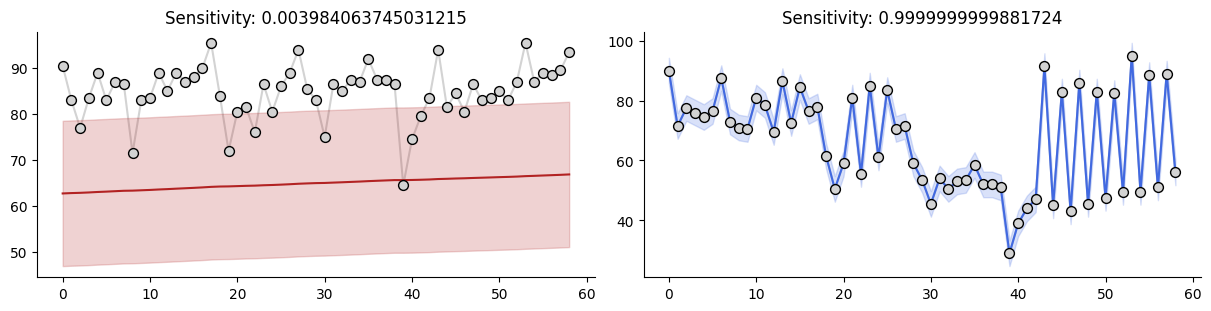

In [17]:
_, axs = plt.subplots(figsize=(12, 3), ncols=2)

# Intero -------------------------
axs[0].scatter(
    np.arange(0, len(heart_rate)),
    heart_rate,
    s=50,
    color="lightgrey",
    edgecolors="k",
)
axs[0].plot(
    np.arange(0, len(heart_rate)),
    heart_rate,
    color="lightgrey",
    zorder=-1,
)

axs[0].plot(
    np.arange(0, len(heart_rate)),
    intero_network.node_trajectories[1]["mean"],
    color="firebricK",
    zorder=-1,
)
std = np.sqrt(1 / intero_network.node_trajectories[0]["precision"])
axs[0].fill_between(
    x=np.arange(0, len(heart_rate)),
    y2=intero_network.node_trajectories[1]["mean"] + std,
    y1=intero_network.node_trajectories[1]["mean"] - std,
    color="firebricK",
    zorder=-1,
    alpha=0.2,
)

sensitivity = intero_network.node_trajectories[0]["precision"][0] / (
    intero_network.node_trajectories[0]["precision"][0]
    + intero_network.node_trajectories[1]["expected_precision"][0]
)

axs[0].set(title=f"Sensitivity: {sensitivity}")

# Extero -------------------------
axs[1].scatter(
    np.arange(0, len(intero_tone_2)),
    intero_tone_2,
    s=50,
    color="lightgrey",
    edgecolors="k",
)
axs[1].plot(
    np.arange(0, len(intero_tone_2)),
    intero_tone_2,
    color="lightgrey",
    zorder=-1,
)

axs[1].plot(
    np.arange(0, len(intero_tone_2)),
    extero_network.node_trajectories[1]["mean"],
    color="royalblue",
    zorder=-1,
)
std = np.sqrt(1 / extero_network.node_trajectories[0]["precision"])
axs[1].fill_between(
    x=np.arange(0, len(heart_rate)),
    y2=extero_network.node_trajectories[1]["mean"] + std,
    y1=extero_network.node_trajectories[1]["mean"] - std,
    color="royalblue",
    zorder=-1,
    alpha=0.2,
)

sensitivity = extero_network.node_trajectories[0]["precision"][0] / (
    extero_network.node_trajectories[0]["precision"][0]
    + extero_network.node_trajectories[1]["expected_precision"][0]
)

axs[1].set(title=f"Sensitivity: {sensitivity}")

sns.despine()